In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

# Phase 1: Setup and Final Data Preparation

In [7]:
df = pd.read_csv("C:/CourseWork/Dissertation Classifying grip strategies using machine learning/data/02_processed/prehension_master_dataset.csv")

print("Prehension Dataset loaded successfully")
print(f"Dateset shape: {df.shape}")

Prehension Dataset loaded successfully
Dateset shape: (2826, 184)


In [9]:
# Feature Selection
# Drop columns that are irrelevant for this analysis
df = df.drop(columns=["onset"])

# Define column types
identifier_cols = ["subjName", "trialN"]
condition_cols = ["visCond", "surface", "distance"]

# All other numeric columns are potential kinematic features
kinematic_features = df.select_dtypes(include=np.number).columns.tolist()
kinematic_features = [col for col in kinematic_features if col not in identifier_cols]

print(f"\nIdentified {len(kinematic_features)} kinematic features")


Identified 178 kinematic features


In [10]:
# Scaling Kinematic Features
X_kinematic = df[kinematic_features].copy()

# Handle any potential missing values 
if X_kinematic.isnull().sum().sum() > 0:
    print("\nWarning: Missing values detected. Filling with the mean")
    X_kinematic = X_kinematic.fillna(X_kinematic.mean())

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X_kinematic)
print("\nKinematic features have been scaled")


Kinematic features have been scaled


# Phase 2: Unsupervised Learning

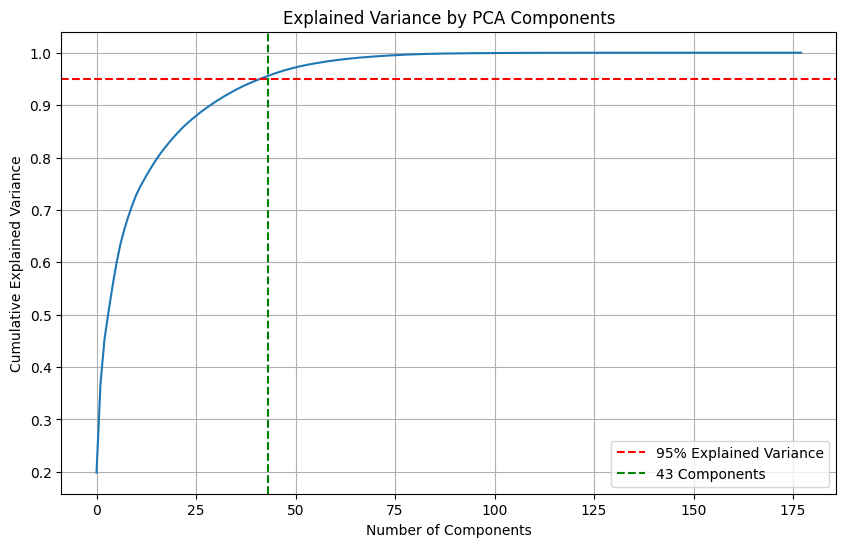

Number of components to expplain 95% of variance: 43
Data transformed using PCA into 43 components


In [14]:
# Dimensionality Reduction (PCA)
pca_test = PCA()
pca_test.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_test.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)

# Components to explain 95% variance
n_components_95 = np.where(np.cumsum(pca_test.explained_variance_ratio_) >= 0.95)[0][0] + 1
plt.axhline(y=0.95, color="r", linestyle="--", label="95% Explained Variance")
plt.axvline(x=n_components_95, color="g", linestyle="--", label=f"{n_components_95} Components")
plt.legend()
plt.show()

print(f"Number of components to expplain 95% of variance: {n_components_95}")

pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_scaled)
print(f"Data transformed using PCA into {X_pca.shape[1]} components")

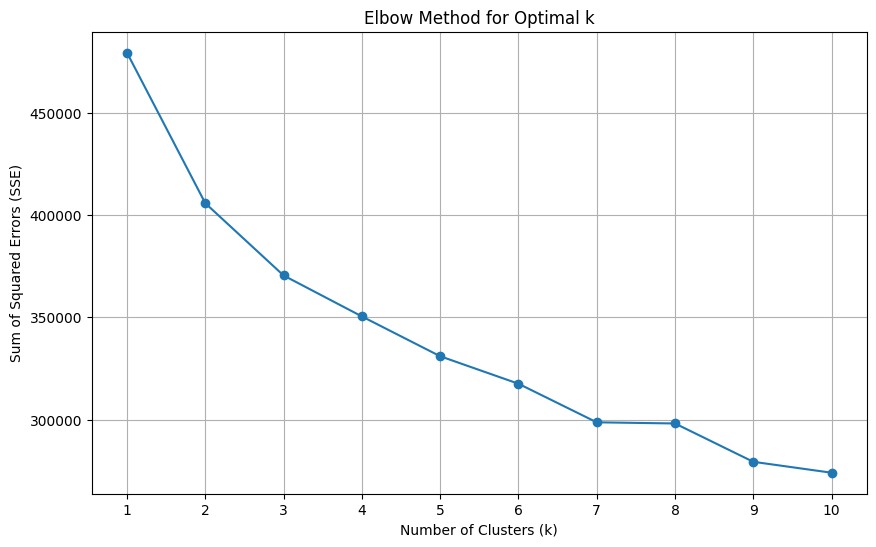

In [ ]:
# Clusstering (K Means)
# FInd optimal number of k using Elbow Method
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [19]:
optimal_k = 4
print(f"Based on this elbow plot, we will proceed with k={optimal_k} clusters")

# Apply K Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=123, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

# Assigning Strategy Labels
df["grip_strategy"] = cluster_labels
print(f"Assigned trials to {optimal_k} grip strategies")

Based on this elbow plot, we will proceed with k=4 clusters
Assigned trials to 4 grip strategies


# Phase 3: Interpretation and Visualisation

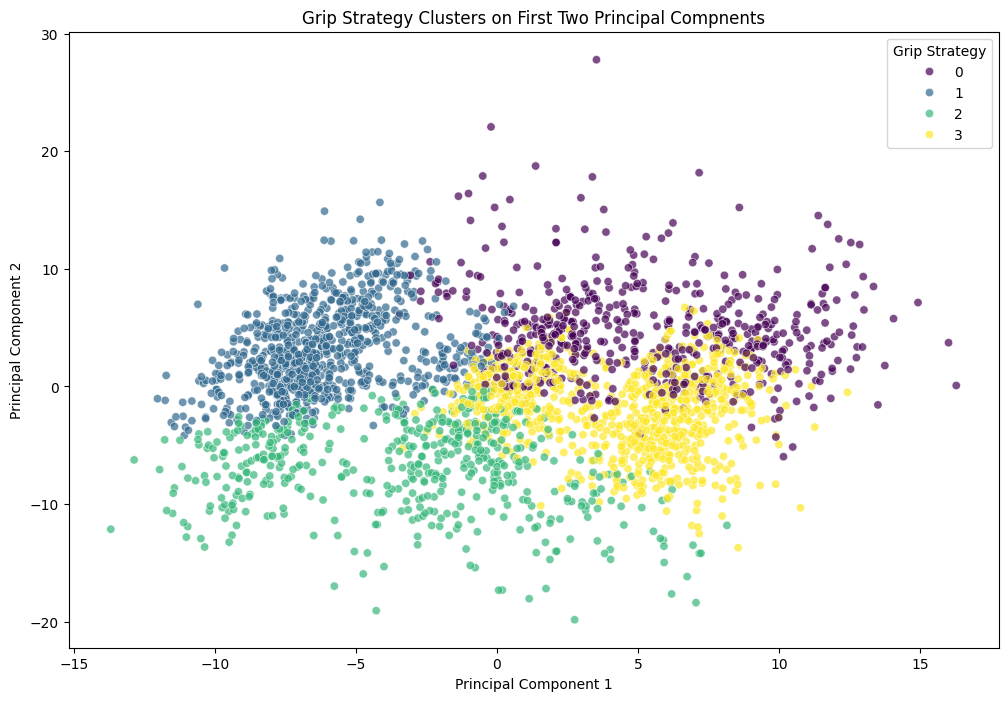

In [20]:
# Visualise Clusters on PCA plot
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=["PC1", "PC2"])
pca_df["grip_strategy"] = cluster_labels

plt.figure(figsize=(12, 8))
sns.scatterplot(x="PC1", y="PC2", hue="grip_strategy", data=pca_df, palette="viridis", alpha=0.7)
plt.title("Grip Strategy Clusters on First Two Principal Compnents")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Grip Strategy")
plt.show()

The clusters are visually distinct, especially Cluster 2 (green) and Cluster 1 (blue). This is strong evidence that there are indeed different, machine-discoverable "strategies" in the data.

In [21]:
# 2. Analyse Cluster Characteristics
key_kinematic_features = ["MGA", "movTime", "MVel_x", "FAcc_x", "pathLength_y"]
cluster_analysis = df.groupby("grip_strategy")[key_kinematic_features].mean()

print("Mean of Key Kinematic Features for each grip strategy")
print(cluster_analysis)

Mean of Key Kinematic Features for each grip strategy
                    MGA   movTime    MVel_x    FAcc_x  pathLength_y
grip_strategy                                                      
0              0.109634  4.153874  1.312472  2.201192      0.499666
1              0.107530  3.798631  0.860054  1.358233      0.966340
2              0.110311  3.573775  1.100796  1.594616      0.437649
3              0.108874  3.791023  1.330569  2.246798      0.522042


In [22]:
# 3. Relate Strategies to Experimental Conditions
print("Relational between discovered strategies and 'distance' condition:")
print(pd.crosstab(df["grip_strategy"], df["distance"]))

print("Relationship between discovered strategies and 'surface' condition: ")
print(pd.crosstab(df["grip_strategy"], df["surface"]))

Relational between discovered strategies and 'distance' condition:
distance       far  middle  near
grip_strategy                   
0              272     264    28
1                2      97   747
2               77     268   172
3              587     312     0
Relationship between discovered strategies and 'surface' condition: 
surface        black  wood
grip_strategy             
0                293   271
1                426   420
2                267   250
3                423   476


## Summary Result

1. Grip Strategy 1 (The "Near-Distance, Corrective Grip"):
    * Evidence: This strategy is used almost exclusively for the near distance (747 trials).
    * Kinematics: It has the highest pathLength_y (0.966) but the lowest MVel_x (0.86).
    * Interpretation: A high path length for a short distance implies a more curved, less direct hand trajectory. The low peak velocity suggests the movement is not ballistic but rather slow and controlled. This is likely a strategy involving more online corrections as the hand approaches a nearby object, prioritizing accuracy over speed.
2. Grip Strategy 3 (The "Far-Distance, Ballistic Reach"):
    * Evidence: This strategy is overwhelmingly used for the far distance (587 trials) and never for the near distance.
    * Kinematics: It has the highest MVel_x (1.33) and highest FAcc_x (2.24).
    * Interpretation: This is a classic fast, powerful, and direct ("ballistic") movement. To cover a large distance, the subject initiates a high-velocity, high-acceleration reach. The primary goal is to cover the distance quickly.
3. Grip Strategy 2 (The "Efficient, Direct Grip"):
    * Evidence: This is a general-purpose strategy, used across all distances but most common for middle and near.
    * Kinematics: It has the lowest movTime (3.57) and the lowest pathLength_y (0.437).
    * Interpretation: This is the most efficient strategy. The movement is quick and follows a very direct path. It seems to be the "default" strategy used when the task is not overly challenging (i.e., not at the extreme far distance). Its tightness on the PCA plot suggests it's a very common and consistent movement pattern.
4. Grip Strategy 0 (The "Careful, Long-Deceleration Grip"):
    * Evidence: Used primarily for far and middle distances.
    * Kinematics: It has the longest movTime (4.15) but a very high MVel_x (1.31), similar to the ballistic strategy.
    * Interpretation: This is a fascinating hybrid. A high peak velocity combined with a long total movement time implies that the hand accelerates quickly but then spends a very long time in the deceleration phase, carefully approaching the target. This might be a strategy used when the object's position or orientation requires very precise final placement.


# Phase 4: Supervised Learning

In [23]:
# 1. Problem Formulation
X_supervised = df[kinematic_features]
y_supervised = df["distance"]

# Encode the target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_supervised)

# 2. Subject Aware Cross Validation
groups = df["subjName"]
group_kfold = GroupKFold(n_splits=5)


In [24]:
# Model Training
pipeline = Pipeline([
    ("scalar", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=123))
])

In [25]:
# Evaluation
print("Performing 5 fold cross validation...")
cv_scores = cross_val_score(pipeline, X_supervised, y_encoded, cv=group_kfold, groups=groups, n_jobs=-1)

print(f"Cross Validation Accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Performing 5 fold cross validation...
Cross Validation Accuracy scores: [0.99821747 1.         1.         1.         0.99644128]
Mean CV Accuracy: 0.9989 (+/- 0.0014)


We got an accuracy of 99.89%. It provides proof that the kinematic features contain a massive amount of information about the target's distance. We can state with high confidence that grasp planning for different distances manifests in measurably different movement patterns.

In [26]:
# 5. Feature Importance
pipeline.fit(X_supervised, y_encoded)
rf_model = pipeline.named_steps["rf"]
importances = rf_model.feature_importances_

C:\Users\bharg\AppData\Local\Temp\ipykernel_64212\214109476.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importance_df.head(20), palette="rocket")


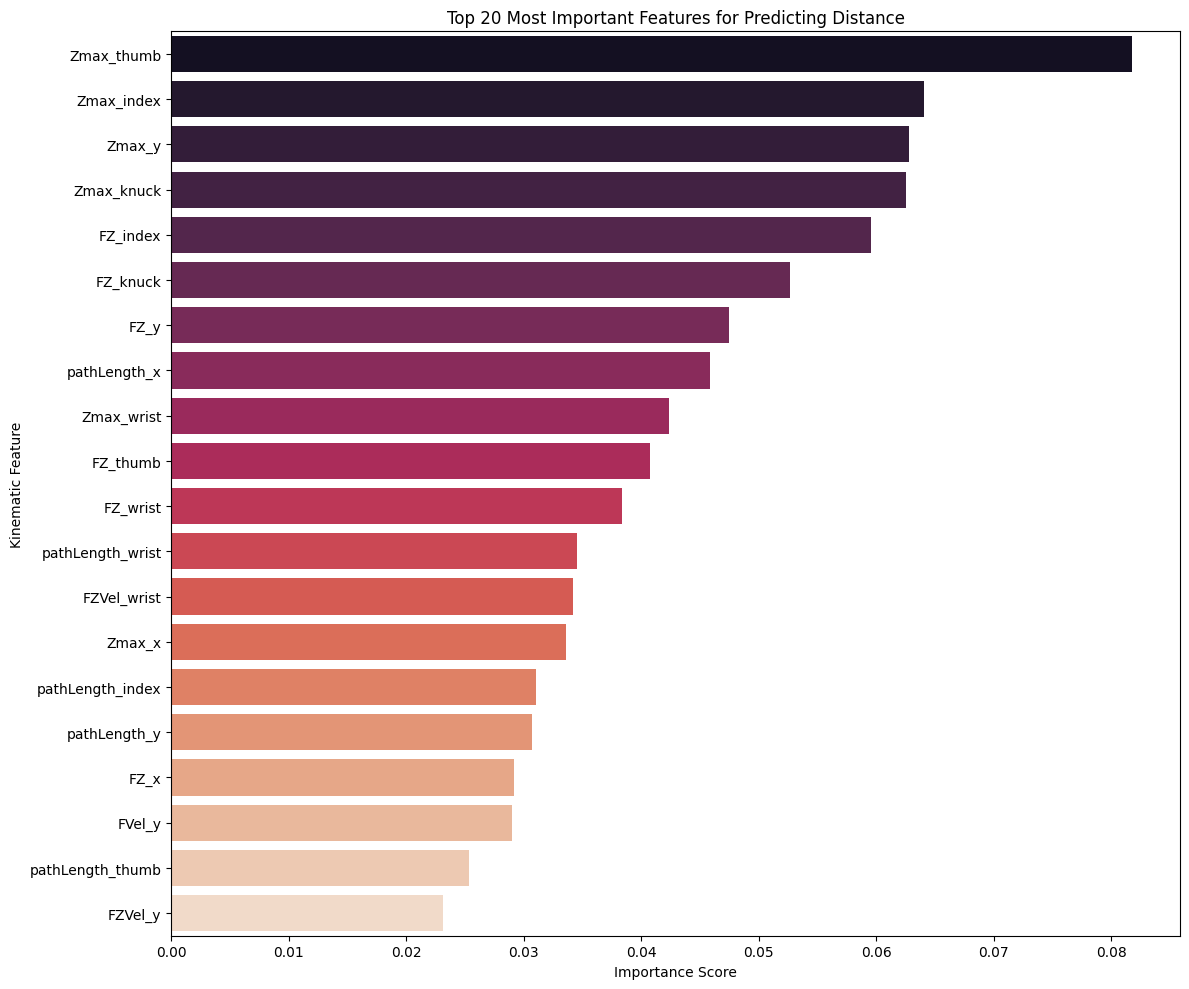


Top 10 most important features:
          feature  importance
136    Zmax_thumb    0.081776
134    Zmax_index    0.064052
32         Zmax_y    0.062813
135    Zmax_knuck    0.062504
82       FZ_index    0.059552
83       FZ_knuck    0.052633
17           FZ_y    0.047499
11   pathLength_x    0.045829
137    Zmax_wrist    0.042393
84       FZ_thumb    0.040734


In [29]:
# Create DataFrame for visualisation
feature_importance_df = pd.DataFrame({
    "feature": kinematic_features,
    "importance": importances
}).sort_values("importance", ascending=False)

# Plot the top 20 most important features
plt.figure(figsize=(12, 10))
sns.barplot(x="importance", y="feature", data=feature_importance_df.head(20), palette="rocket")
plt.title("Top 20 Most Important Features for Predicting Distance")
plt.xlabel("Importance Score")
plt.ylabel("Kinematic Feature")
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feature_importance_df.head(10))

The model found that Zmax_thumb, Zmax_index, and Zmax_y are the most important features. The Z-axis in motion capture typically represents depth (forward/backward movement).

It reveals that the most reliable way to predict how far someone reaches is by looking at the maximum forward position their hand and fingers achieve. While factors like velocity and acceleration do play a role, the model shows that the final point of the reach carries the strongest signal. This actually aligns with common sense — we naturally think of a reach in terms of where it ends — but now, the model confirms it with data. Additionally, the force applied in the Z-direction (FZ_...) also turned out to be important, further emphasizing that the forward-driving aspect of the movement is what primarily determines how far the hand travels.